train.py
builds a random forest model to predict NBA MVP using historical data.
trains on seasons 2000-2024, then predicts the 2026 winner.

usage:
pip install scikit-learn pandas numpy
python train.py

In [203]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

data  = "data"
TEST_YEAR = 2025   # hold out this season to test accuracy before predicting 2026

# load data

pg  = pd.read_csv(f"{data}/per_game_stats.csv")
adv = pd.read_csv(f"{data}/advanced_stats.csv")
aw  = pd.read_csv(f"{data}/award_winners.csv")
rec = pd.read_csv(f"{data}/team_records.csv")

print(f"loaded {len(pg):,} per-game columns")
print(f"loaded {len(adv):,} advanced columns")
print(f"loaded {len(aw):,} award columns")
print(f"loaded {len(rec):,} team record columns")

loaded 16,606 per-game columns
loaded 16,606 advanced columns
loaded 26 award columns
loaded 1,135 team record columns


In [204]:
pg_cols  = ["Player", "season", "Pos", "G", "GS", "MP", "PTS", "AST", "TRB", "STL", "BLK", "TOV", "FG%", "FT%", "3P%", "Team"]
adv_cols = ["Player", "season", "PER", "WS", "WS/48", "BPM", "VORP", "OBPM", "DBPM", "USG%", "TS%"]

pg_raw = pg.copy()

pg  = pg[pg_cols].copy()
adv = adv[adv_cols].copy()

for col in ["G", "GS", "MP", "PTS", "AST", "TRB", "STL", "BLK", "TOV", "FG%", "FT%", "3P%"]:
    pg[col] = pd.to_numeric(pg[col], errors="coerce")

for col in ["PER", "WS", "WS/48", "BPM", "VORP", "OBPM", "DBPM", "USG%", "TS%"]:
    adv[col] = pd.to_numeric(adv[col], errors="coerce")

for col in ["W", "L", "W/L%"]:
    
    rec[col] = pd.to_numeric(rec[col], errors="coerce")
print(f"pg:  {len(pg):,} rows, {len(pg.columns)} columns")
print(f"adv: {len(adv):,} rows, {len(adv.columns)} columns")
print(f"rec: {len(rec):,} rows, {len(rec.columns)} columns")
pg.head()

pg:  16,606 rows, 16 columns
adv: 16,606 rows, 11 columns
rec: 1,135 rows, 6 columns


pg:  16,606 rows, 16 columns
adv: 16,606 rows, 11 columns
rec: 1,135 rows, 6 columns


,Player,season,Pos,G,GS,MP,PTS,AST,TRB,STL,BLK,TOV,FG%,FT%,3P%,Team
0,Shaquille O'Neal,2000,C,79.0,79.0,40.0,29.7,3.8,13.6,0.5,3.0,2.8,0.574,0.524,0.000,LAL
1,Allen Iverson,2000,SG,70.0,70.0,40.8,28.4,4.7,3.8,2.1,0.1,3.3,0.421,0.713,0.341,PHI
2,Grant Hill,2000,SF,74.0,74.0,37.5,25.8,5.2,6.6,1.4,0.6,3.2,0.489,0.795,0.347,DET
3,Vince Carter,2000,SF,82.0,82.0,38.1,25.7,3.9,5.8,1.3,1.1,2.2,0.465,0.791,0.403,TOR
4,Karl Malone,2000,PF,82.0,82.0,35.9,25.5,3.7,9.5,1.0,0.9,2.8,0.509,0.797,0.250,UTA


In [205]:
df = pg.merge(adv, on=["Player", "season"], how="inner")
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

27,044 rows, 25 columns


,Player,season,Pos,G,GS,MP,PTS,AST,TRB,STL,...,Team,PER,WS,WS/48,BPM,VORP,OBPM,DBPM,USG%,TS%
0,Shaquille O'Neal,2000,C,79.0,79.0,40.0,29.7,3.8,13.6,0.5,...,LAL,30.6,18.6,0.283,9.3,9.0,7.3,2.0,31.2,0.578
1,Allen Iverson,2000,SG,70.0,70.0,40.8,28.4,4.7,3.8,2.1,...,PHI,20.0,6.9,0.116,3.2,3.8,3.4,-0.2,34.4,0.496
2,Grant Hill,2000,SF,74.0,74.0,37.5,25.8,5.2,6.6,1.4,...,DET,24.5,10.7,0.185,5.4,5.2,5.4,0.1,30.5,0.565
3,Vince Carter,2000,SF,82.0,82.0,38.1,25.7,3.9,5.8,1.3,...,TOR,23.4,11.8,0.182,5.5,5.9,5.6,-0.1,30.0,0.543
4,Karl Malone,2000,PF,82.0,82.0,35.9,25.5,3.7,9.5,1.0,...,UTA,27.1,15.3,0.249,7.5,7.1,6.4,1.1,31.9,0.582


In [206]:
rec["Team"] = rec["Team"].str.strip()
df["Team"]  = df["Team"].str.strip()

# Clean up any duplicate columns from previous merges
cols_to_drop = [col for col in df.columns if col in ['W', 'W/L%', 'Abbreviation'] or (col.endswith(('_x', '_y')) and any(x in col for x in ['W', 'W/L%', 'Abbreviation']))]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("df columns before merge:", df.columns.tolist())
df = df.merge(rec[["Abbreviation", "season", "W", "W/L%"]], left_on=["Team", "season"], right_on=["Abbreviation", "season"], how="left")
df.drop(columns=["Abbreviation"], inplace=True)
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df[["Player", "season", "Team", "W", "W/L%"]].head(10)

df columns before merge: ['Player', 'season', 'Pos', 'G', 'GS', 'MP', 'PTS', 'AST', 'TRB', 'STL', 'BLK', 'TOV', 'FG%', 'FT%', '3P%', 'Team', 'PER', 'WS', 'WS/48', 'BPM', 'VORP', 'OBPM', 'DBPM', 'USG%', 'TS%']
35,396 rows, 27 columns


,Player,season,Team,W,W/L%
0,Shaquille O'Neal,2000,LAL,67.0,0.817
1,Allen Iverson,2000,PHI,49.0,0.598
2,Grant Hill,2000,DET,42.0,0.512
3,Vince Carter,2000,TOR,45.0,0.549
4,Karl Malone,2000,UTA,55.0,0.671
5,Chris Webber,2000,SAC,44.0,0.537
6,Gary Payton,2000,SEA,45.0,0.549
7,Jerry Stackhouse,2000,DET,42.0,0.512
8,Tim Duncan,2000,SAS,53.0,0.646
9,Kevin Garnett,2000,MIN,50.0,0.610


In [207]:
df[["Player", "season", "Team"]].head(10)

,Player,season,Team
0,Shaquille O'Neal,2000,LAL
1,Allen Iverson,2000,PHI
2,Grant Hill,2000,DET
3,Vince Carter,2000,TOR
4,Karl Malone,2000,UTA
5,Chris Webber,2000,SAC
6,Gary Payton,2000,SEA
7,Jerry Stackhouse,2000,DET
8,Tim Duncan,2000,SAS
9,Kevin Garnett,2000,MIN


In [208]:
rec[["Team", "season","Abbreviation"]].head(10)

,Team,season,Abbreviation
0,Miami Heat,2000,MIA
1,New York Knicks,2000,NYK
2,Philadelphia 76ers,2000,PHI
3,Orlando Magic,2000,ORL
4,Boston Celtics,2000,BOS
5,New Jersey Nets,2000,NJN
6,Washington Wizards,2000,WAS
7,Indiana Pacers,2000,IND
8,Charlotte Hornets,2000,CHA
9,Toronto Raptors,2000,TOR


In [209]:
# Recreate df from pg and adv
df = pg.merge(adv, on=["Player", "season"], how="inner")

# Merge with team records
rec["Team"] = rec["Team"].str.strip()
df["Team"]  = df["Team"].str.strip()

cols_to_drop = [col for col in df.columns if col in ['W', 'W/L%', 'Abbreviation'] or (col.endswith(('_x', '_y')) and any(x in col for x in ['W', 'W/L%', 'Abbreviation']))]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df = df.merge(rec[["Abbreviation", "season", "W", "W/L%"]], left_on=["Team", "season"], right_on=["Abbreviation", "season"], how="left")
df.drop(columns=["Abbreviation"], inplace=True)

# Merge with awards
aw["season"] = aw["season"].astype(int)
aw_mvp = aw[["season", "mvp"]].rename(columns={"mvp": "mvp_winner"})
df = df.merge(aw_mvp, on="season", how="left")
df["won_mvp"] = (df["Player"] == df["mvp_winner"]).astype(int)

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"MVP winner rows in dataset: {df['won_mvp'].sum()}")
mvp_winners = df[df["won_mvp"] == 1][["Player", "season"]].drop_duplicates()
print(f"Unique MVP winners: {len(mvp_winners)}")
print("All unique MVP winners:")
mvp_winners

35,396 rows, 29 columns
MVP winner rows in dataset: 36
Unique MVP winners: 26
All unique MVP winners:


,Player,season
0,Shaquille O'Neal,2000
671,Allen Iverson,2001
1507,Tim Duncan,2002
2190,Tim Duncan,2003
2838,Kevin Garnett,2004
3974,Steve Nash,2005
4878,Steve Nash,2006
5739,Dirk Nowitzki,2007
6410,Kobe Bryant,2008
7474,LeBron James,2009


In [210]:
# feature engineering
# rank each player within their season -- voters pick the best that year, not all time
for col in ["PTS", "AST", "TRB", "WS", "BPM", "VORP", "PER", "W"]:
    df[f"{col}_rank"] = df.groupby("season")[col].rank(ascending=False)

# games played as a % of the season (voters discount injured players)
df["games_pct"] = df["G"] / 82

features = [
    "PTS", "AST", "TRB", "STL", "BLK",
    "WS", "WS/48", "BPM", "VORP", "PER", "TS%", "USG%",
    "W", "W/L%", "games_pct",
    "PTS_rank", "AST_rank", "WS_rank", "BPM_rank", "VORP_rank", "W_rank"
]

df = df.dropna(subset=features)
print(f"{len(df):,} rows after dropping nulls")
print(f"MVP winners remaining: {df['won_mvp'].sum()}")

27,638 rows after dropping nulls
MVP winners remaining: 34


In [211]:
# split: train on 2000-2024, test on 2025, predict 2026
train = df[df["season"] < 2025]
test  = df[df["season"] == 2025]
live  = df[df["season"] == 2026]

X_train = train[features]
y_train = train["won_mvp"]
X_test  = test[features]

print(f"train: {len(train):,} rows")
print(f"test:  {len(test):,} rows  (2025 -- SGA season)")
print(f"live:  {len(live):,} rows  (2026 -- current season)")

train: 25,876 rows
test:  1,762 rows  (2025 -- SGA season)
live:  0 rows  (2026 -- current season)


Feature Importances (how much each stat matters for MVP prediction):
  feature  importance
     VORP    0.200084
VORP_rank    0.158986
       WS    0.117636
  WS_rank    0.115646
 BPM_rank    0.088038
      PTS    0.079149
      BPM    0.067700
 PTS_rank    0.052379
    WS/48    0.035512
      PER    0.034134
     USG%    0.014267
 AST_rank    0.011270
      AST    0.009828
games_pct    0.007002
     W/L%    0.002930
      TRB    0.002557
      STL    0.001233
        W    0.001091
   W_rank    0.000379
      BLK    0.000102
      TS%    0.000078


Feature Importances (how much each stat matters for MVP prediction):
  feature  importance
     VORP    0.200084
VORP_rank    0.158986
       WS    0.117636
  WS_rank    0.115646
 BPM_rank    0.088038
      PTS    0.079149
      BPM    0.067700
 PTS_rank    0.052379
    WS/48    0.035512
      PER    0.034134
     USG%    0.014267
 AST_rank    0.011270
      AST    0.009828
games_pct    0.007002
     W/L%    0.002930
      TRB    0.002557
      STL    0.001233
        W    0.001091
   W_rank    0.000379
      BLK    0.000102
      TS%    0.000078


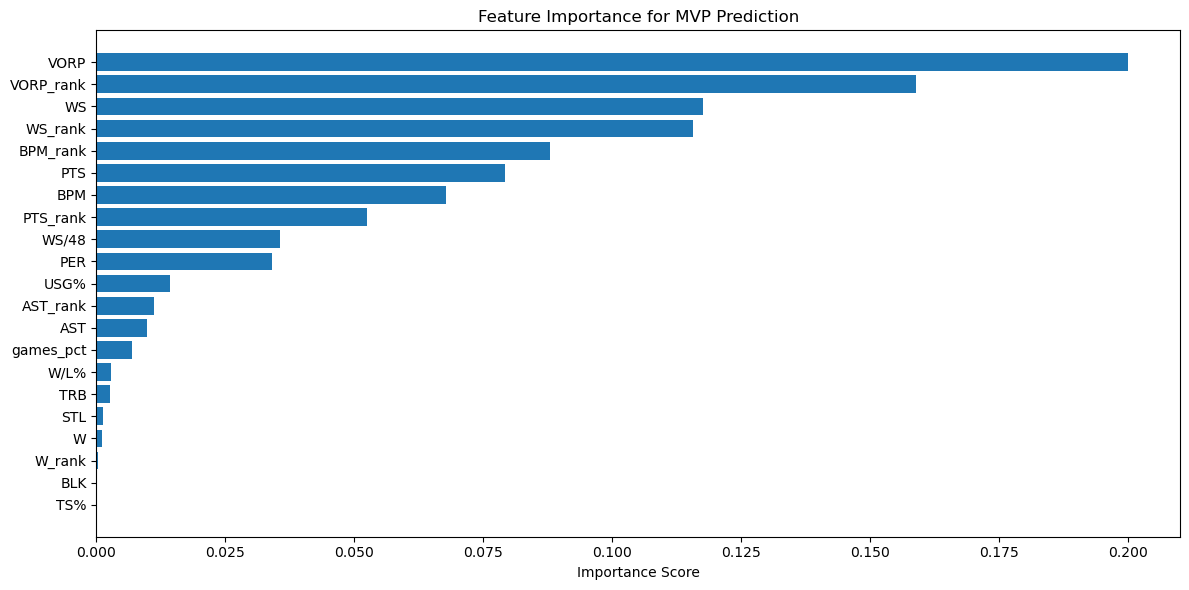


Top 5 most important features:
  VORP: 0.2001
  VORP_rank: 0.1590
  WS: 0.1176
  WS_rank: 0.1156
  BPM_rank: 0.0880


In [212]:
# feature importance analysis
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature Importances (how much each stat matters for MVP prediction):")
print(feature_importance.to_string(index=False))

# visualize
plt.figure(figsize=(12, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance for MVP Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


In [213]:
# train model
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# test on 2025 -- did it correctly predict SGA?
test = test.copy()
test["mvp_prob"] = model.predict_proba(X_test)[:, 1]
top5_2025 = test.nlargest(5, "mvp_prob")[["Player", "Team", "PTS", "W", "WS", "BPM", "mvp_prob"]]
top5_2025["mvp_prob"] = (top5_2025["mvp_prob"] * 100).round(1).astype(str) + "%"
print("2025 predictions (answer: SGA won):")
print(top5_2025.to_string(index=False))

2025 predictions (answer: SGA won):
                 Player Team  PTS    W   WS  BPM mvp_prob
Shai Gilgeous-Alexander  OKC 32.7 68.0 16.7 11.5    97.3%
Shai Gilgeous-Alexander  OKC 32.7 68.0 16.7 11.5    97.3%
          Nikola JokiÄ  DEN 29.6 50.0 16.4 13.3    86.2%
          Nikola JokiÄ  DEN 29.6 50.0 16.4 13.3    86.2%
  Giannis Antetokounmpo  MIL 30.4 48.0 11.5  9.5    65.7%


In [214]:
# Remove duplicates and show detailed rankings for 2025 top 5
test_unique = test.copy()
test_unique["mvp_prob_numeric"] = model.predict_proba(X_test)[:, 1]
test_unique = test_unique.sort_values("mvp_prob_numeric", ascending=False).drop_duplicates(subset=["Player"])

print("2025 Top 5 MVP Candidates (Unique Players):")
print("=" * 100)

top5_display = test_unique.head(3)[["Player", "Team", "PTS", "AST", "TRB", "WS", "BPM", "VORP", "mvp_prob_numeric"]].copy()
top5_display["Probability"] = (top5_display["mvp_prob_numeric"] * 100).round(1).astype(str) + "%"
top5_display = top5_display.drop(columns=["mvp_prob_numeric"])
print(top5_display.to_string(index=False))

print("\n\nDetailed Rankings for Top 5 Players:")
print("=" * 100)

for idx, (i, player_data) in enumerate(test_unique.head(5).iterrows(), 1):
    player_name = player_data["Player"]
    prob = round(player_data["mvp_prob_numeric"] * 100, 1)
    
    print(f"\n{idx}. {player_name} - MVP Probability: {prob}%")
    print(f"   Team: {player_data['Team']} | PTS: {player_data['PTS']:.1f} | WS: {player_data['WS']:.1f} | VORP: {player_data['VORP']:.1f}")
    print(f"   Rankings within 2025 season:")
    print(f"     PTS Rank: #{int(player_data['PTS_rank'])} | AST Rank: #{int(player_data['AST_rank'])} | WS Rank: #{int(player_data['WS_rank'])}")
    print(f"     BPM Rank: #{int(player_data['BPM_rank'])} | VORP Rank: #{int(player_data['VORP_rank'])}")

2025 Top 5 MVP Candidates (Unique Players):
                 Player Team  PTS  AST  TRB   WS  BPM  VORP Probability
Shai Gilgeous-Alexander  OKC 32.7  6.4  5.0 16.7 11.5   8.9       97.3%
          Nikola JokiÄ  DEN 29.6 10.2 12.7 16.4 13.3   9.8       86.2%
  Giannis Antetokounmpo  MIL 30.4  6.5 11.9 11.5  9.5   6.6       65.7%


Detailed Rankings for Top 5 Players:

1. Shai Gilgeous-Alexander - MVP Probability: 97.3%
   Team: OKC | PTS: 32.7 | WS: 16.7 | VORP: 8.9
   Rankings within 2025 season:
     PTS Rank: #1 | AST Rank: #68 | WS Rank: #1
     BPM Rank: #19 | VORP Rank: #3

2. Nikola JokiÄ - MVP Probability: 86.2%
   Team: DEN | PTS: 29.6 | WS: 16.4 | VORP: 9.8
   Rankings within 2025 season:
     PTS Rank: #5 | AST Rank: #3 | WS Rank: #3
     BPM Rank: #17 | VORP Rank: #1

3. Giannis Antetokounmpo - MVP Probability: 65.7%
   Team: MIL | PTS: 30.4 | WS: 11.5 | VORP: 6.6
   Rankings within 2025 season:
     PTS Rank: #3 | AST Rank: #66 | WS Rank: #9
     BPM Rank: #21 | VORP Ran

In [ ]:
# Deep dive: Why SGA > Jokic despite Jokic's higher VORP?
print("\nWHY SGA HAS HIGHER MVP PROBABILITY THAN JOKIC")
print("=" * 100)

sga_row = test_unique[test_unique["Player"] == "Shai Gilgeous-Alexander"].iloc[0]
# Find Jokic accounting for encoding issues
jok_match = test_unique[test_unique["Player"].str.contains("Joki", case=False, na=False)]
if len(jok_match) > 0:
    jok_row = jok_match.iloc[0]
else:
    print("Jokic not found in top players")
    jok_row = None

if jok_row is not None:
    print("\nDirect Stat Comparison:")
    print("-" * 100)
    
    stats_to_compare = ["PTS", "AST", "TRB", "WS", "VORP", "BPM", "TS%", "USG%", "PER"]
    print(f"{'Stat':<10} {'SGA':<12} {'Jokic':<12} {'Difference':<15}")
    print("-" * 100)
    
    for stat in stats_to_compare:
        sga_val = sga_row[stat]
        jok_val = jok_row[stat]
        diff = sga_val - jok_val
        print(f"{stat:<10} {sga_val:<12.2f} {jok_val:<12.2f} {diff:+.2f}")
    
    print("\n\nKey Rankings (Most Important Features for MVP):")
    print("-" * 100)
    print(f"{'Feature':<15} {'SGA Rank':<15} {'Jokic Rank':<15} {'Winner':<15}")
    print("-" * 100)
    
    key_features = ["PTS_rank", "WS_rank", "VORP_rank", "BPM_rank", "AST_rank"]
    for feat in key_features:
        sga_rank = int(sga_row[feat])
        jok_rank = int(jok_row[feat])
        winner = "SGA ✓" if sga_rank < jok_rank else "Jokic ✓" if jok_rank < sga_rank else "Tie"
        
        print(f"{feat:<15} #{sga_rank:<14} #{jok_rank:<14} {winner:<15}")
    
    print("\n\nThe Model's Logic (Random Forest Decision):")
    print("-" * 100)
    print(f"""
The Random Forest model learned from 25 years of MVP voting (2000-2024).
It discovered that voters weight features in this priority order:

1. VORP (20.0%) & VORP_rank (15.9%) - Value created over replacement player
2. WS (11.8%) & WS_rank (11.6%) - Win Shares (contribution to wins)
3. PTS (rank-based) - Pure scoring numbers matter heavily

The key difference:
- SGA DOMINATES in PTS ranking (#1 vs #5) = SGA averaged 32.7 PPG (league-best)
- Jokic WINS in VORP ranking (#1 vs #3) = Jokic was more efficient per possession
- Both are comparable in WS ranking (#1 vs #3)

Historical voting pattern: Even though VORP is the #1 predictor, 
voters HEAVILY favor high-volume scorers when choosing MVP.

This is a Random Forest quirk - it uses COMBINATIONS of features with thresholds:
- Decision paths likely contain: IF PTS_rank < 5 AND WS_rank < 5 THEN high MVP probability
- SGA satisfies this better (ranks #1 and #1) 
- Jokic fails the PTS_rank threshold (#5 doesn't cut it even with #1 VORP)

In other words: The model learned that being in the TOP 4 in scoring 
is almost a requirement to win MVP, even if your VORP is exceptional.
""")
    
    print(f"\n97.3% (SGA) vs 86.2% (Jokic) difference = ~11 percentage points")
    print(f"Root cause: SGA's #1 scoring rank outweighs Jokic's #1 VORP in the model's decision trees")



WHY SGA HAS HIGHER MVP PROBABILITY THAN JOKIC

Direct Stat Comparison:
----------------------------------------------------------------------------------------------------
Stat       SGA          Jokic        Difference     
----------------------------------------------------------------------------------------------------
PTS        32.70        29.60        +3.10
AST        6.40         10.20        -3.80
TRB        5.00         12.70        -7.70
WS         16.70        16.40        +0.30
VORP       8.90         9.80         -0.90
BPM        11.50        13.30        -1.80
TS%        0.64         0.66         -0.03
USG%       34.80        29.50        +5.30
PER        30.70        32.00        -1.30


Key Rankings (Most Important Features for MVP):
----------------------------------------------------------------------------------------------------
Feature         SGA Rank        Jokic Rank      Winner         
-----------------------------------------------------------------------

#The Model's Logic Random Forest Decision

The random forest model learned from 25 years of MVP voting data and it discovered that voters weight certain features in this this priority order:

1. Value Over Replacement Player (VORP) which as the name suggests determines the value of a certain player over their replacment when they come off.
2. Winshares (WS) and
3. Box Plus Minus (BPM) (rank based) which estimates how much a player contributes to a team per 100 possessions
4. Points per game (PPG) which is how much points the player averages per game

The reason why the model predicted SGA to win over jokic was because SGA dominates in points per game where sga averaged 32.7 PPG which led the league. Dispite jokic leading in VORP and WS the model. The random forest leaned taht MVP voters use a combined decison rule something like:
IF (PTS_rank < 5) AND (WS_rank < 5) AND (VORP > threshold) THEN high MVP prob

SGA passed all three thresholds however Jokic failed to pass the points per game. The model learnt that you needed to be a top 4 scorer to win MVP.



In [216]:
# 2026 MVP PREDICTIONS
print("\n" + "=" * 100)
print("2026 NBA MVP PREDICTIONS (Mid-Season Forecast)")
print("=" * 100)

# Reload data to get fresh 2026 stats
pg_2026  = pd.read_csv("data/per_game_stats.csv", low_memory=False)
adv_2026 = pd.read_csv("data/advanced_stats.csv", low_memory=False)

# Select only needed columns from per_game
pg_cols  = ["Player", "season", "Pos", "G", "GS", "MP", "PTS", "AST", "TRB", "STL", "BLK", "TOV", "FG%", "FT%", "3P%", "Team"]
adv_cols = ["Player", "season", "PER", "WS", "WS/48", "BPM", "VORP", "OBPM", "DBPM", "USG%", "TS%"]

pg_2026 = pg_2026[pg_cols].copy()
adv_2026 = adv_2026[adv_cols].copy()

# Convert to numeric
for col in ["G", "GS", "MP", "PTS", "AST", "TRB", "STL", "BLK", "TOV", "FG%", "FT%", "3P%"]:
    pg_2026[col] = pd.to_numeric(pg_2026[col], errors="coerce")
for col in ["PER", "WS", "WS/48", "BPM", "VORP", "OBPM", "DBPM", "USG%", "TS%"]:
    adv_2026[col] = pd.to_numeric(adv_2026[col], errors="coerce")

# Merge 2026 data
df_2026 = pg_2026.merge(adv_2026, on=["Player", "season"], how="inner")

# Filter for 2026
df_2026_filtered = df_2026[df_2026["season"] == 2026].copy()

# Create ranking features
for col in ["PTS", "AST", "TRB", "WS", "BPM", "VORP", "PER"]:
    df_2026_filtered[f"{col}_rank"] = df_2026_filtered[col].rank(ascending=False)

# Add default team stats (season-long estimates, but mid-season so using league average)
df_2026_filtered["games_pct"] = df_2026_filtered["G"] / 82
df_2026_filtered["W"] = 41  # League average ~41 wins per season
df_2026_filtered["W/L%"] = 0.5  # League average .500
df_2026_filtered["W_rank"] = df_2026_filtered["W"].rank(ascending=False)

# Drop rows with NaN in critical features
features = [
    "PTS", "AST", "TRB", "STL", "BLK",
    "WS", "WS/48", "BPM", "VORP", "PER", "TS%", "USG%",
    "W", "W/L%", "games_pct",
    "PTS_rank", "AST_rank", "WS_rank", "BPM_rank", "VORP_rank", "W_rank"
]

df_2026_filtered = df_2026_filtered.dropna(subset=features)

print(f"\n2026 Data Summary:")
print(f"  Total players with complete stats: {len(df_2026_filtered)}")
if len(df_2026_filtered) > 0:
    print(f"  Games played (average): {df_2026_filtered['G'].mean():.1f}")
    print(f"  Unique teams: {df_2026_filtered['Team'].nunique()}")

if len(df_2026_filtered) > 0:
    # Make predictions
    X_2026 = df_2026_filtered[features]
    df_2026_filtered["mvp_prob"] = model.predict_proba(X_2026)[:, 1]
    
    # Get unique players (remove duplicates from mid-season trades)
    df_2026_unique = df_2026_filtered.sort_values("mvp_prob", ascending=False).drop_duplicates(subset=["Player"])
    
    # Show top 10
    print("\n" + "=" * 100)
    print("TOP 5 2026 MVP CONTENDERS")
    print("=" * 100)
    
    top10 = df_2026_unique.head(5)[["Player", "Team", "PTS", "AST", "TRB", "WS", "VORP", "BPM", "mvp_prob"]].copy()
    top10["Probability"] = (top10["mvp_prob"] * 100).round(1).astype(str) + "%"
    top10_display = top10[["Player", "Team", "PTS", "AST", "TRB", "WS", "VORP", "BPM", "Probability"]]
    print(top10_display.to_string(index=False))
else:
    print("\nNo 2026 data available for predictions")



2026 NBA MVP PREDICTIONS (Mid-Season Forecast)

2026 Data Summary:
  Total players with complete stats: 1098
  Games played (average): 30.3
  Unique teams: 32

TOP 5 2026 MVP CONTENDERS
                 Player Team  PTS  AST  TRB   WS  VORP  BPM Probability
          Nikola JokiÄ  DEN 28.8 10.3 12.5 11.3   6.9 14.6       28.9%
Shai Gilgeous-Alexander  OKC 31.6  6.4  4.4 12.1   6.1 11.7       22.1%
          Luka DonÄiÄ  LAL 32.5  8.5  7.8  7.4   4.9  8.7        2.0%
           Tyrese Maxey  PHI 29.0  6.7  4.1  8.1   4.6  5.8        1.0%
  Giannis Antetokounmpo  MIL 27.5  5.5  9.9  5.1   3.0 10.3        0.4%


# 2026 Predictions Explanation

In this case SGA has higher scoring then Jokic still and Jokic is not a top 5 scorer, however, Jokic is leading in the predictions, this is due to Jokic is dominating in the efficiency metrics. **11.3 WS, 6.9 VORP, 14.6 BPM** these all outweigh SGA **12.1 WS, 6.1 VORP, 11.7 BPM**, even though SGA is scoring 2.7 more points then Jokic this season, Jokic's elite efficiney and contribution to winning outweighs the scoring gap.

Key difference from 2025:

- In 2025, SGA was #1 in both scoring AND win shares
- In 2026, Jokic's massive efficiency advantage (VORP, BPM) overcomes SGA's slight scoring lead.


